In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

## Задача 1

In [ ]:
df = pd.read_csv('t1.csv',sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
q1 = df['молоко'].quantile(0.25)
q3 = df['молоко'].quantile(0.75)
Q = q3 - q1
mn = df[df['день'] == 'воскресенье']['молоко'].median()
hyper_up = mn + 3 * Q
hyper_down = mn - 3 * Q
df['молоко'] = np.where((df['день'] == 'воскресенье') & (df['молоко'] > hyper_up), mn, df['молоко'])
if mn % 1 == 0:
    df['молоко'] = df['молоко'].astype('int64')
print(df.head(25))

           день  молоко
0   понедельник     105
1       вторник     139
2         среда     134
3       четверг     130
4       пятница     139
5       суббота     131
6   воскресенье      54
7   понедельник     136
8       вторник     125
9         среда     130
10      четверг     121
11      пятница     138
12      суббота     127
13  воскресенье     112
14  понедельник     146
15      вторник     130
16        среда     140
17      четверг     141
18      пятница     122
19      суббота     139
20  воскресенье      54
21  понедельник     140
22      вторник     131
23        среда     123
24      четверг     128


## Задача 2

На этот раз вы работаете в компании, которая обслуживает сервис по продаже автомобилей с пробегом. Поступила задача на разработку приложения для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. На первом шаге построения прогнозной модели нужно проанализировать данные на пропуски и заполнить их. Этим вам и предстоит заняться.

Необходимо сделать:

В данных VehicleType были обнаружены пропуски. Причём по группе бренд-марка встречается несколько строк. Вам нужно заполнить их по такому правилу: вставить наиболее часто встречаемый тип кузова у сочетания бренд-марка.
Пример: Если по сочетанию “volkswagen-golf” наиболее встречаемый тип кузова “small”. Поэтому Nan надо заполнить именно этим кузовом. Если по группе бренд-марка нет данных по кузову, то такие строки заполнить группой “unknown”.

Сформировать сводную таблицу из таких столбцов [Brand, VehicleType, Price].
Цену вставить медианную по группам [Brand, VehicleType].
Таблицу отсортировать по цене в порядке убывания и вывести первые первые 10 строк. Нумерацию индексов сделать заново. Названия столбцов использовать как в задании.
Данные находятся в файле data.csv.
Разделитель значений - точка с запятой. Разделителем дробных чисел применяется запятая. В таблице даны семь столбцов.

In [ ]:
import pandas as pd

df = pd.read_csv('t2.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
bt = df.groupby(['Brand', 'Model', 'VehicleType']).size().reset_index(name='count')
result = bt.sort_values('count', ascending=False).drop_duplicates(['Brand', 'Model'])[['Brand', 'Model', 'VehicleType']]
result_dict = dict(zip(result['Brand'] + '-' + result['Model'], result['VehicleType']))
df['VehicleType'] = df['VehicleType'].fillna((df['Brand'] + '-' + df['Model']).map(result_dict).fillna('unknown'))
df['MedianPrice'] = df.groupby(['Brand', 'VehicleType'])['Price'].transform('median')
df_new = df[['Brand', 'VehicleType', 'MedianPrice']].drop_duplicates().sort_values('MedianPrice', ascending=False).head(10).reset_index(drop=True)
print(df_new)

           Brand  VehicleType  MedianPrice
0     volkswagen          suv      15600.0
1            bmw          suv      14800.0
2      chevrolet        wagon      13499.0
3          skoda          suv      13200.0
4  mercedes_benz  convertible      12790.0
5          volvo  convertible      12400.0
6     volkswagen        coupe      11500.0
7        porsche  convertible      10450.0
8         nissan        coupe      10200.0
9        peugeot          bus      10000.0


           Brand  VehicleType    Price
0     volkswagen          suv  15600.0
1            bmw          suv  14800.0
2      chevrolet        wagon  13499.0
3          skoda          suv  13200.0
4  mercedes_benz  convertible  12790.0


## Задача 3

In [ ]:
df = pd.read_csv('t3.csv',sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['вес'] = df['вес'].ffill()
nans = df['затрачиваемая_мощность'].isna().to_list()
df['interpolate'] = [True if ((nans[i] and not nans[i - 1] and not nans[i + 1]) or (not nans[i - 1] and nans[i] and nans[i + 1])) else False for i in range(len(nans))]
df['затрачиваемая_мощность'] = np.where(df['interpolate'], df['затрачиваемая_мощность'].interpolate(method='linear'), df['затрачиваемая_мощность'])
df['медиана_по_группе'] = df.groupby('key')['затрачиваемая_мощность'].transform('median')
df['затрачиваемая_мощность'] = df['затрачиваемая_мощность'].fillna(df['медиана_по_группе'])
df_new = df.groupby('key').agg({'вес': 'sum', 'затрачиваемая_мощность': 'sum'}).reset_index(drop='key')
df_new = df_new.map(lambda x: (x + 0.5)).astype('int64').astype('float')
print(df_new.head(30))

        вес  затрачиваемая_мощность
0    9630.0                    39.0
1    7938.0                    37.0
2    9589.0                    41.0
3    8089.0                    36.0
4    7945.0                    33.0
5    7920.0                    36.0
6    7944.0                    35.0
7    7983.0                    38.0
8    9540.0                    45.0
9   11090.0                    61.0
10   9606.0                    39.0
11   7976.0                    33.0
12  11276.0                    52.0
13  11161.0                    50.0
14   9633.0                    44.0
15   6387.0                    28.0
16   9607.0                    45.0
17   9572.0                    43.0
18   6448.0                    29.0
19   9572.0                    44.0
20  11239.0                    50.0
21  11093.0                    52.0
22   9608.0                    41.0
23  11062.0                    53.0
24  11114.0                    49.0
25   6389.0                    31.0
26   7960.0                 

In [ ]:

print(df.head(3))

      вес  затрачиваемая_мощность
0  9630.0                    39.0
1  7938.0                    37.0
2  9589.0                    41.0


## Задача 4

In [ ]:
df = pd.read_csv('t4.csv',sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['групповая_медиана'] = df.groupby(['покупательская_активность', 'тип_товара'])['выручка'].transform('median')
df['выручка'] = df['выручка'].fillna(df['групповая_медиана'])
q1 = df['выручка'].quantile(0.25)
q3 = df['выручка'].quantile(0.75)
Q = q3 - q1
mn = df['выручка'].median()
upper_bound = mn + 3 * Q
ans = [['показатель', 'р-уровень', 'метод расчёта']]
df['выручка'] = np.where(df['выручка'] > upper_bound, df['групповая_медиана'], df['выручка'])
g1_ = df[(df['тип_товара'] == 'товары для себя') & (df['покупательская_активность'] == 'Снизилась')]
g2_ = df[(df['тип_товара'] == 'товары для себя') & (df['покупательская_активность'] == 'Прежний уровень')]
df = df.drop(columns=['покупательская_активность', 'тип_товара', 'групповая_медиана'])
for column in df.columns:
    g1 = g1_[column]
    g2 = g2_[column]
    if st.shapiro(g1)[1] >= 0.05 and st.shapiro(g2)[1] >= 0.05:
        ans.append([column, float(st.ttest_ind(g1, g2)[1]), 'Стьюдент'])
    else:
        ans.append([column, float(st.mannwhitneyu(g1, g2)[1]), 'Манн-Уитни'])
print(ans)

[['показатель', 'р-уровень', 'метод расчёта'], ['история_продаж', 0.011086004180878649, 'Манн-Уитни'], ['неоплаченные_товары', 3.130334685326147e-22, 'Манн-Уитни'], ['выручка', 0.005601148616075883, 'Манн-Уитни']]


In [ ]:

quantile, groupby, transform

[['показатель', 'р-уровень', 'метод расчёта р-уровня'], ['история_продаж', 0.0111, 'Манн-Уитни'], ['неоплаченные_товары', 0.0, 'Манн-Уитни'], ['выручка', 0.0056, 'Манн-Уитни']]


In [ ]:
m_test

[['показатель', 'р-уровень', 'метод расчёта р-уровня'],
 ['история_продаж', 0.0111, 'Манн-Уитни'],
 ['неоплаченные_товары', 0.0, 'Манн-Уитни'],
 ['выручка', 0.0056, 'Манн-Уитни']]

## Задача 5

ford


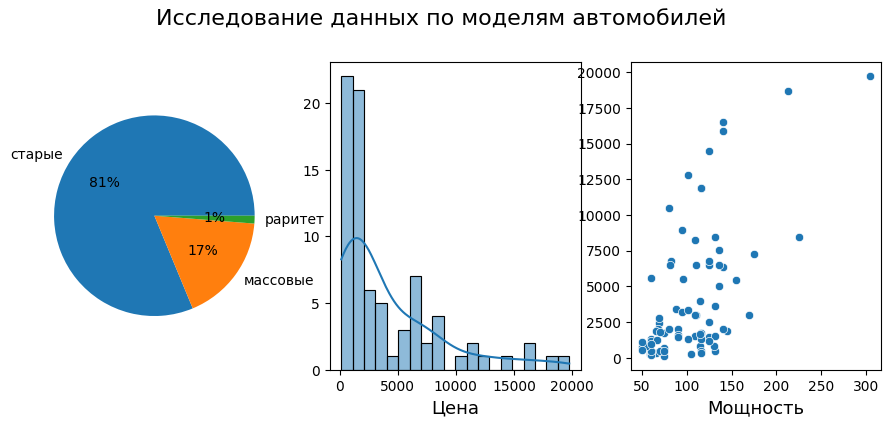

In [ ]:
df = pd.read_csv('t5.csv',sep=';', encoding='cp1251', skipinitialspace=True)
df.columns = df.columns.str.lower().str.replace(' ', '_')
def f(x):
  if x <= 1980:
    return 'раритет'
  elif 1980 < x <= 2010:
    return 'старые'
  elif 2010 < x <= 2020:
    return 'массовые'
  else:
    return 'современные'
df['new_factor'] = df['registrationyear'].apply(f)
brand = input()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
fig.suptitle('Исследование данных по моделям автомобилей',
             fontsize=16,
             y=1.01)

def floor(pct):
    return f'{np.floor(pct):.0f}%'

df_sorted = df[(df['brand'] == brand) & (df['power'] > 30) & (df['price'] > 0)]
fr = df_sorted['new_factor'].value_counts()
axes[0].pie(fr, labels=fr.index, autopct=floor)

sns.histplot(data=df_sorted, x='price', bins=20, kde=True, ax=axes[1])
axes[1].set_xlabel('Цена', fontsize=13)
axes[1].set_ylabel('')

sns.scatterplot(data=df_sorted, x='power', y='price', ax=axes[2])
axes[2].set_xlabel('Мощность', fontsize=13)
axes[2].set_ylabel('')
plt.savefig('target_6_5.png')
plt.show()

**********************************************************************************************